**Import Libraries**

In [123]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**Data Import**

In [124]:
heart_dis = pd.read_csv('/content/heart_disease_uci.csv')

**Check the top rows of dataset**

In [125]:
heart_dis.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


**Check the Shape of data**

In [126]:
heart_dis.shape

(920, 16)

**Check the Size of data**

In [127]:
heart_dis.size

14720

**Check Dtypes**

In [128]:
heart_dis.dtypes

,0
id,int64
age,int64
sex,object
dataset,object
cp,object
trestbps,float64
chol,float64
fbs,object
restecg,object
thalch,float64


**Check the Duplicates in Data**

In [129]:
heart_dis.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
915,False
916,False
917,False
918,False


*There is no duplicates present in data*

**Check the info about data**

In [130]:
heart_dis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


**See the summary of data**

In [131]:
heart_dis.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


**Check Null/missing Values**





In [132]:
heart_dis.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


*Yes, there is nulls values present in data*

**Checking null values percentange in each category of data**

In [133]:
missing_pct = (heart_dis.isnull().sum() / len(heart_dis)) * 100
missing_pct.sort_values(ascending=False)

,0
ca,66.413043
thal,52.826087
slope,33.586957
fbs,9.782609
oldpeak,6.739130
trestbps,6.413043
exang,5.978261
thalch,5.978261
chol,3.260870
restecg,0.217391


*Missing %	Action
*< 5–10%	Impute
*10–30%	Impute carefully
*> 40%	Drop



**Replace or map the string values into integer for thal column includes missing values**

In [134]:
thal_map = {
    "normal": 0,
    "fixed defect": 1,
    "reversable defect": 2
}

heart_dis["thal"] = heart_dis["thal"].map(thal_map)


*converted the string into integer for "thal" column and then handling the missing values with KNN imputer*

**Check Dtpyes again for "thal"**

In [135]:
heart_dis.dtypes

,0
id,int64
age,int64
sex,object
dataset,object
cp,object
trestbps,float64
chol,float64
fbs,object
restecg,object
thalch,float64


*It has converted into float now*

**Import KNN Imputer from sklearn Lib**

In [136]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
heart_dis[["ca","thal"]] = imputer.fit_transform(heart_dis[["ca","thal"]])


*Now, have applied KNN Imputer for columns"thal"and "ca"*

**Now Check again the missing values for "thal" and "ca"**

In [137]:
missing_pct = (heart_dis.isnull().sum() / len(heart_dis)) * 100
missing_pct.sort_values(ascending=False)

,0
slope,33.586957
fbs,9.782609
oldpeak,6.739130
trestbps,6.413043
thalch,5.978261
exang,5.978261
chol,3.260870
restecg,0.217391
cp,0.000000
age,0.000000


*there is no nulls present in "thal" and "ca" columns , all has been removed now*

**Treatment for other missing values columns**

In [138]:
num_cols = ["oldpeak","trestbps","thalch","chol"]

for c in num_cols:
    heart_dis[c].fillna(heart_dis[c].median(), inplace=True)


/tmp/ipython-input-1524719662.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  heart_dis[c].fillna(heart_dis[c].median(), inplace=True)


*imputed median value with the nulls*

In [139]:
cat_cols = ["slope","fbs","exang","restecg"]

for c in cat_cols:
    heart_dis[c].fillna(heart_dis[c].mode()[0], inplace=True)


/tmp/ipython-input-85945122.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  heart_dis[c].fillna(heart_dis[c].mode()[0], inplace=True)
/tmp/ipython-input-85945122.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heart_dis[c].fillna(heart_dis[c].mode()[0], inplace=True)


*imputes mode value with the nulls*

In [140]:
missing_pct = (heart_dis.isnull().sum() / len(heart_dis)) * 100  # all treated well
missing_pct.sort_values(ascending=False)

,0
id,0.0
age,0.0
sex,0.0
dataset,0.0
cp,0.0
trestbps,0.0
chol,0.0
fbs,0.0
restecg,0.0
thalch,0.0


*Check again for nulls but there is no missing values left, all are treated well..*

#NON-GRAPHICAL ANALYSIS

In [141]:
heart_dis.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [142]:
heart_dis['id'].value_counts()

,count
id,
920,1
1,1
2,1
3,1
4,1
...,...
13,1
12,1
11,1


In [143]:
heart_dis['age'].value_counts().sort_values(ascending=True)

,count
age,
30,1
73,1
28,1
76,2
77,2
31,2
33,2
29,3
75,3


* Most heart disease cases are in middle-aged people (50–60 years)
* Very few young patients
* Risk increases with age

In [144]:
heart_dis['sex'].value_counts()

,count
sex,
Male,726
Female,194


In [145]:
heart_dis['sex'].value_counts(normalize=True)*100


,proportion
sex,
Male,78.913043
Female,21.086957


* Dataset is gender imbalanced
* 79% male, 21% female

* Males = 726 (≈79%)
* Females = 194 (≈21%)
* Around 4 males for every 1 female

In [146]:
heart_dis['dataset'].value_counts()

,count
dataset,
Cleveland,304
Hungary,293
VA Long Beach,200
Switzerland,123


In [147]:
heart_dis['dataset'].value_counts(normalize= True)*100

,proportion
dataset,
Cleveland,33.043478
Hungary,31.847826
VA Long Beach,21.739130
Switzerland,13.369565


* Largest Dataset Source

Cleveland (304) → Highest contribution

Very close to Hungary (293)
-------------------------------------------
* Smallest Dataset Source

Switzerland (123) → Lowest records
-----------------------------------------
* Distribution Percentage (Approx)

Cleveland → 33%

Hungary → 32%

VA Long Beach → 22%

Switzerland → 13%

* Data is not perfectly balanced across locations.







In [148]:
heart_dis['cp'].value_counts()

,count
cp,
asymptomatic,496
non-anginal,204
atypical angina,174
typical angina,46


About cp feature:
cp (in heart dataset)

cp stands for:

Chest Pain Type

It shows the type of chest pain a patient experiences.

Common categories:

0 → Typical angina

1 → Atypical angina

2 → Non-anginal pain

3 → Asymptomatic

-->Certain chest pain types (especially typical angina) are strongly linked to heart disease risk.

------------------------------------->>>>>>>>>>>>>>>>>>>>>>

* Most Common Type

Asymptomatic → 496 (~54%)

--> More than half of patients have no chest pain symptoms.

This is important ⚠ because heart disease can exist without visible chest pain.

* Second Most Common

Non-anginal → 204 (~22%)

--> Chest pain not related to heart.

* Less Common Types

Atypical angina → 174 (~19%)

Typical angina → 46 (~5%) (very low)

--> Classic chest pain (typical angina) is rare in this dataset.

Most patients are asymptomatic
* Typical angina cases are very low
* Chest pain type is likely an important predictive feature
* Disease may exist even without chest pain

In [149]:
heart_dis['trestbps'].value_counts().sort_values(ascending= False)

,count
trestbps,
130.0,174
120.0,131
140.0,102
110.0,59
150.0,56
...,...
92.0,1
185.0,1
0.0,1


About trestbps feature:
trestbps stands for:

Resting Blood Pressure

It measures the patient’s blood pressure at rest (in mm Hg).

Simple meaning:

Higher trestbps → Higher resting blood pressure

High blood pressure can increase heart disease risk

--------------------------->>>>>>>>>>>>>>>>>>>>>>>>

* Most Common BP Level

130 → 174 people (highest)

120 → 131 people

140 → 102 people

--> Most patients are between 120–140 mmHg

* Majority Have Slightly High BP

Normal BP ≈ 120 mmHg

But many patients are:

130

140

150

160

--> This shows many patients have elevated or high blood pressure

* Very High BP Present

Some patients have:

160 (50)

170 (40)

165+

150+

--> High BP is common in this dataset.

* Very Low BP is Rare

90–100 range → very few patients

--> Most people are not low BP patients.
------------------------------------------------------------

* Most patients have BP around 120–140
* Many have high blood pressure (≥140)
* High BP may be strong risk factor for heart disease



In [150]:
heart_dis['chol'].value_counts()

,count
chol,
0.0,172
223.0,39
220.0,10
254.0,10
204.0,9
...,...
165.0,1
337.0,1
333.0,1


About chol feature:

Most patients (782) have normal fasting blood sugar.

A small group (138) have high fasting blood sugar.

The data is highly imbalanced toward the “False” category.

------------------------------------->>>>>>>>>>>>>>>>>>>


* Most Common Real Cholesterol Values

223 → 39 people

220 → 10

254 → 10

204 → 9

-->Most values are between 200–250 mg/dL

* High Cholesterol Present

Some extreme values:

333

337

385

-->These are very high and risky levels.

* Distribution Insight

Normal cholesterol < 200
200–239 → borderline
240+ → high

Since many values are above 200 →
* Many patients have elevated cholesterol.

* Many patients have borderline/high cholesterol

In [151]:
heart_dis['fbs'].value_counts()

,count
fbs,
False,782
True,138


About fbs feature:
fbs stands for:

Fasting Blood Sugar

It shows whether a patient’s fasting blood sugar level is high.

Values usually mean:

0 → Fasting blood sugar ≤ 120 mg/dl (normal)

1 → Fasting blood sugar > 120 mg/dl (high)

->High fasting blood sugar may increase the risk of heart disease.

------------------------------------------------------------------>>>>>>

Most patients (782) have normal fasting blood sugar.

A small group (138) have high fasting blood sugar.

The data is highly imbalanced toward the “False” category.



In [152]:
heart_dis['restecg'].value_counts()

,count
restecg,
normal,553
lv hypertrophy,188
st-t abnormality,179


In [153]:
heart_dis['restecg'].value_counts(normalize=True)*100

,proportion
restecg,
normal,60.108696
lv hypertrophy,20.434783
st-t abnormality,19.456522


About restecg feature:

restecg (in heart dataset)

restecg stands for:

Resting Electrocardiographic Results

It shows the ECG results when the patient is at rest (not exercising).

Common values mean:

0 → Normal

1 → ST-T wave abnormality

2 → Left ventricular hypertrophy (LVH)

--> Abnormal resting ECG results may indicate higher risk of heart disease.


------------------------------------------------------>>>>>>>>>>>>>>

* Majority Are Normal

553 patients (~60%) have normal ECG

--> Most patients show normal electrical heart activity at rest.

* Abnormal ECG Exists in ~40%

LV hypertrophy → 188 (~20%)

ST-T abnormality → 179 (~19%)

--> Around 4 out of 10 patients have abnormal ECG

* Meaning of Each Type (Simple)
* Normal

Heart electrical activity looks normal.

* LV Hypertrophy

Left ventricle wall is thickened
--> Usually due to high BP
--> Increases heart disease risk

* ST-T Abnormality

Abnormal heart signal pattern
--> May indicate ischemia (reduced blood flow)

insights:

* Most patients are normal
* But 40% show ECG abnormalities
* LV hypertrophy & ST-T changes may indicate higher heart risk


In [154]:
heart_dis['thalch'].value_counts()

,count
thalch,
140.0,96
150.0,43
120.0,35
130.0,30
160.0,26
...,...
63.0,1
67.0,1
107.0,1


About thalch feature:Thalach = Maximum Heart Rate Achieved
It represents the highest heart rate reached during the exercise test.

Simple meaning:

Higher thalch → Heart was able to reach higher rate during exercise

Lower thalch → May indicate heart-related issues
---------------------------------------------------->>>>>>>>>>>>


* Most Common Heart Rate

140 → 96 patients (highest)

150 → 43

120 → 35

130 → 30

160 → 26

--> Most patients are between 120–160 bpm

* Normal vs Risk Meaning

Normal max heart rate depends on age
Formula (approx):

220 − age


Lower max heart rate during stress test may indicate heart problem.

* Very Low Values Exist

Values like:

63

67

69

73

--> Very low maximum heart rate
--> Could indicate poor heart performance

# insights

* Most patients have moderate max heart rate (120–160)
* Some very low values may indicate higher risk
* Often negatively correlated with heart disease
(Lower heart rate → higher disease chance)

In [155]:
heart_dis['exang'].value_counts()

,count
exang,
False,583
True,337


**About feature:**

exang (Exercise-Induced Angina)

exang means exercise-induced angina.

It shows whether a patient gets chest pain during exercise.

False (0) → No chest pain during exercise.

True (1) → Chest pain occurs during exercise

Insights:

Majority of patients (583) do not have exercise-induced angina.

A significant portion (337) do experience exercise-induced angina.

The feature shows a moderate class imbalance.

Since 337 cases are positive, exang could be an important predictor for heart disease.

In [156]:
heart_dis['oldpeak'].value_counts()

,count
oldpeak,
0.0,370
1.0,83
0.5,81
2.0,76
1.5,48
3.0,28
1.2,17
2.5,16
0.8,15


ABout oldpeak feature:

Old → old ST segment value (comparison reference)

Peak → peak exercise level

So oldpeak measures how much the ST segment decreases during peak exercise compared to rest in an ECG test.

oldpeak means ST depression induced by exercise relative to rest.

It measures how much the ST segment drops during an exercise ECG test.

Higher oldpeak values often indicate higher heart disease risk.

Lower values (especially near 0) usually suggest a more normal heart response.

------------------------------------>>>>>>>>>>>>>>>>>>>>


Majority values are low

0.0 → 370 cases (very high)

0.5 → 81

1.0 → 83

2.0 → 76

-->Most patients have low ST depression (0–2 range).

* Highly Right-Skewed Distribution

Counts decrease as value increases.

Very few values above 3.0

Extreme values like 5.6, 6.2 appear only once.

--> Indicates positive skewness.

* Very Few Negative Values

Some negatives (-0.5, -1.0, -2.6 etc.)

But extremely rare.

--> Negative oldpeak is uncommon in dataset.

* Potential Outliers

Values like:
6.2

5.6

-2.6

--> These may act as outliers and influence linear models.

* Clinical Meaning (If Heart Dataset)

In heart disease datasets:

Low oldpeak (0–1) → Normal / low ST depression

High oldpeak (>2) → Higher chance of heart disease

--> If correlated with target, higher values may indicate higher risk.

* Insights:

* Dataset dominated by low oldpeak values
* Highly skewed distribution
* Few extreme outliers


In [157]:
heart_dis['slope'].value_counts()

,count
slope,
flat,654
upsloping,203
downsloping,63


About slope feature:

slope means the slope of the ST segment during peak exercise (from ECG test).

It shows how the heart responds during stress or exercise.

Types:

Upsloping → Generally considered more normal.

Flat → May indicate possible heart issues.

Downsloping → Often associated with higher risk of heart disease




* Most patients (654) have a flat slope(indicate possible heart issues)

* A smaller group (203) shows an upsloping pattern(Normal)

* Very few patients (63) have a downsloping pattern(higher risk of heart disease)

* The data is clearly dominated by the flat slope category.

In [158]:
heart_dis['ca'].value_counts()

,count
ca,
0.676375,476
0.000000,181
1.000000,142
2.000000,41
1.400000,32
1.600000,28
3.000000,20


About ca(Coronary Arteries) feature:Number of Major Coronary Arteries (0–3) colored by Fluoroscopy

ca means the number of major blood vessels (0–3) colored by fluoroscopy.

It shows how many vessels are visible during a special heart imaging test.

Higher values of ca often indicate greater blockage or heart disease risk.

Lower values (especially 0) usually suggest less severe blockage.

---------------------------------------------------------->>>>>>>>>>

Insights:

Most values are concentrated around 0.676 (476 cases), making it the most frequent value.

A large number of patients have 0.0 (181 cases) and 1.0 (142 cases).

Higher values like 2.0 and 3.0 are much less common.

The distribution decreases as the ca value increases.


In [159]:
heart_dis['thal'].value_counts()

,count
thal,
0.990783,476
0.000000,196
2.000000,192
1.000000,46
0.800000,8
0.400000,2


About Thal(Thalassemia test result) feature:

It shows the result of a blood disorder test related to oxygen-carrying capacity of blood.

In most heart datasets, values mean:

0 → Normal

1 → Fixed defect

2 → Reversible defect

--> Reversible and fixed defects are often linked to higher heart disease risk.



Insights:

Most patients (476) fall into one dominant thal category (0.990783).

A large number also belong to categories 0.0 (196) and 2.0 (192).

Very few patients are in 1.0 (46) and other minor categories.

The distribution is imbalanced, with one category clearly dominating.

Decimal values suggest the feature may have been scaled or transformed.

In [160]:
heart_dis['num'].value_counts()

,count
num,
0,411
1,265
2,109
3,107
4,28


About num feature:

num represents the diagnosis of heart disease.

It is usually the target variable in the dataset.

Values mean:

0 → No heart disease

1, 2, 3, 4 → Presence of heart disease (increasing severity)

--> In many projects, we convert it into:

0 → No disease

1 → Disease present (1–4 combined)





Most patients (411) are in category 0, meaning no heart disease.

A significant number (265) are in category 1.

Fewer patients fall into higher categories 2 (109) and 3 (107).

Very few patients (28) are in category 4.

The dataset is slightly imbalanced, with more non-disease cases than severe cases.

**column num be converted into binary (0 vs 1)?**

In [161]:
heart_dis["target"] = (heart_dis["num"] > 0).astype(int)


In [162]:
heart_dis["target"]

,target
0,0
1,1
2,1
3,0
4,0
...,...
915,1
916,0
917,1
918,0


*converted num column into binary columns as a named "target".*

**Which numeric column has highest variance ?**

In [163]:
heart_dis.select_dtypes(include="number").var().idxmax()


'id'

In [164]:
heart_dis.select_dtypes(include="number").var().sort_values(ascending=False)


,0
id,70610.000000
chol,11889.758793
thalch,632.282858
trestbps,340.450471
age,88.824691
num,1.305748
oldpeak,1.119467
thal,0.423226
ca,0.339822
target,0.247432


id has the highest variance (70610)

But

id is just an identifier

It has no medical meaning, so it must be dropped before modeling.
---------------------------------------------------------------------------->

Highest meaningful variance (medical features)

After ignoring id:

--->chol (cholesterol) has the highest variance = 11889

Cholesterol values vary a lot across patients

It may carry strong predictive information

It should definitely be scaled/normalized.

**Average cholesterol by num?**

In [165]:
#heart_dis.groupby("num")["chol"].mean()


In [166]:
heart_dis.groupby("target")["chol"].mean() # here we are using target (binary)


,chol
target,
0,227.678832
1,177.485265


* Patients without heart disease (target = 0) have higher average cholesterol (~228).

* Patients with heart disease (target = 1) have lower average cholesterol (~177).

**How many patients have heart disease?**

In [167]:
heart_dis["num"].value_counts(normalize=True)*100


,proportion
num,
0,44.673913
1,28.804348
2,11.847826
3,11.630435
4,3.043478


Insights:

* Most patients fall in category 0 (44.7%), meaning no heart disease.

* Categories 1 (28.8%) form a large portion of the data.

* Fewer patients are in categories 2 (11.8%) and 3 (11.6%).

* Very few patients are in category 4 (3.0%), indicating severe cases are rare.

conclusion:

The pivot is dominated by patients with no heart disease (44.7%), followed by mild disease cases in category 1 (28.8%). Moderate disease categories (2 and 3) each account for around 12% of the data. Severe heart disease cases (category 4) are relatively rare at just 3.0%. Overall, the target variable shows a clear class imbalance toward non-disease and mild disease cases.

**How does the mean age vary across different heart disease severity levels (num)?**

In [168]:
heart_dis.groupby("num")["age"].mean()


,age
num,
0,50.547445
1,53.528302
2,57.577982
3,59.214953
4,59.214286


Insights:

* Average age increases as heart disease severity increases.

* Patients with no heart disease (num = 0) are the youngest on average (~50.5 years).

* Patients in higher severity groups (num = 3 and 4) are the oldest (~59 years).

* This suggests age is positively associated with heart disease severity.

Conclusion:

The analysis shows a clear upward trend in average age with increasing heart disease severity. Patients without heart disease (num = 0) have the lowest mean age at approximately 50.5 years, while those in higher severity categories (num = 3 and 4) have the highest mean age at around 59 years. This pattern indicates that older age is associated with more severe heart disease. Overall, age appears to be an important demographic factor in disease progression.




**Average resting BP by num?**

In [169]:
heart_dis.groupby("target")["trestbps"].mean()


,trestbps
target,
0,129.917275
1,133.673870


Insight:

Patients with heart disease (target = 1) have slightly higher resting blood pressure (~134).

Patients without heart disease (target = 0) have lower average resting blood pressure (~130).

This suggests higher resting blood pressure may be linked to heart disease.

Conclusion:

Patients diagnosed with heart disease (target = 1) show a higher average resting blood pressure (approximately 133.7 mm Hg) compared to those without heart disease (approximately 129.9 mm Hg). Although the difference is modest, it indicates a potential association between elevated resting blood pressure and the presence of heart disease. Resting blood pressure may therefore contribute as a supporting clinical indicator in heart disease prediction models.

**Mean heart rate (thalch) by disease status?**

In [170]:
heart_dis.groupby("target")["thalch"].mean()


,thalch
target,
0,148.372263
1,129.068762


Insights:

* Patients without heart disease (target = 0) have a higher average maximum heart rate (~148).

* Patients with heart disease (target = 1) have a lower average maximum heart rate (~129).

* Lower maximum heart rate may be associated with heart disease.

Conclusion:

The analysis indicates a clear difference in maximum heart rate achieved between the two groups. Patients without heart disease (target = 0) have a higher average maximum heart rate (approximately 148 bpm), while patients with heart disease (target = 1) show a notably lower average value (approximately 129 bpm). This suggests that reduced exercise capacity, as reflected by lower maximum heart rate, is associated with the presence of heart disease and may serve as an important predictive feature.



**Average oldpeak for diseased vs healthy?**

In [171]:
heart_dis.groupby("target")["oldpeak"].mean()


,oldpeak
target,
0,0.422384
1,1.201179


Insights:

* Patients with heart disease (target = 1) have higher average oldpeak (~1.20).

* Patients without heart disease (target = 0) have much lower oldpeak (~0.42).

* Higher oldpeak values are associated with heart disease.

Conclusion:

The results show a clear difference in average oldpeak values between the two groups. Patients with heart disease (target = 1) have a significantly higher mean oldpeak (approximately 1.20) compared to those without heart disease (approximately 0.42). This indicates that greater ST depression during exercise is strongly associated with the presence of heart disease, making oldpeak a potentially important predictive feature.



**Disease percentage by gender?**

In [172]:
heart_dis.groupby("sex")["target"].mean() * 100


,target
sex,
Female,25.773196
Male,63.223140


Insights:

* Male patients have a much higher average target value than female patients.

* Heart disease is more common among males in this dataset.

* Gender appears to be associated with heart disease presence.

Conclusion:

The analysis reveals a substantial difference in heart disease prevalence between genders. Male patients exhibit a significantly higher average target value compared to female patients, indicating a greater occurrence of heart disease among males in this dataset. This suggests that gender may be an important demographic factor associated with heart disease risk.



**Disease percentage by chest pain type?**

In [173]:
heart_dis.groupby("cp")["target"].mean() * 100


,target
cp,
asymptomatic,79.032258
atypical angina,13.793103
non-anginal,35.784314
typical angina,43.478261


Insights:

* Patients with asymptomatic chest pain show the highest heart disease presence.

* Typical angina and non-anginal pain have moderate association with heart disease.

* Atypical angina shows the lowest heart disease occurrence.

Conclusion:

The distribution of heart disease varies notably across chest pain types. Patients with asymptomatic chest pain exhibit the highest prevalence of heart disease, indicating a strong association with adverse cardiac outcomes. Typical angina and non-anginal chest pain show a moderate relationship with heart disease presence, while atypical angina is associated with the lowest prevalence. This suggests that chest pain type is a clinically significant feature in heart disease risk assessment.





**Disease rate for each thal category?**


In [174]:
heart_dis.groupby("thal")["target"].mean() * 100


,target
thal,
0.000000,29.591837
0.400000,100.000000
0.800000,37.500000
0.990783,53.991597
1.000000,76.086957
2.000000,80.208333


Insights:

* Heart disease presence varies clearly across thal categories.

* Higher target values are seen in several thal groups, especially around 1.0 and 2.0.

* Some thal categories show very high disease presence, though with fewer cases.

* This indicates that thal is an important feature linked to heart disease.


Conclusion:

The analysis demonstrates a strong variation in heart disease prevalence across different thal categories. Higher target values are observed in several groups, particularly for thal values around 1.0 and 2.0, indicating a stronger association with heart disease. Certain categories exhibit very high disease prevalence, although they likely represent smaller sample sizes. Overall, the results suggest that thal is a clinically significant feature in predicting heart disease risk.

**Is cholesterol different between healthy and diseased?**

In [175]:
heart_dis.groupby("num")['chol'].mean()

,chol
num,
0,227.678832
1,195.988679
2,145.311927
3,160.308411
4,193.250000


Insights:

* Cholesterol levels vary across heart disease severity categories.

* Patients with no heart disease (num = 0) have the highest average cholesterol.

* Lower average cholesterol is observed in moderate disease groups (num = 2 and 3).

* Cholesterol alone does not show a clear increasing trend with disease severity.

Conclusion:

The analysis shows that average cholesterol levels differ across heart disease severity categories but do not follow a consistent increasing pattern. Patients without heart disease (num = 0) exhibit the highest mean cholesterol level, while lower averages are observed in moderate severity groups (num = 2 and 3). Cholesterol levels rise again in the most severe category (num = 4), though with fewer cases. Overall, cholesterol alone does not demonstrate a clear linear relationship with heart disease severity and may have limited standalone predictive value.


 **Gender vs disease**

In [176]:
pd.crosstab(heart_dis["sex"], heart_dis["num"], margins=True)


num,0,1,2,3,4,All
sex,,,,,,
Female,144,30,10,8,2,194
Male,267,235,99,99,26,726
All,411,265,109,107,28,920


Insights:

* Most patients in the dataset are male (726) compared to female (194).

* Heart disease is more common among males across all severity levels.

* Females are mostly concentrated in the no disease (num = 0) category.

* Severe heart disease cases (num = 4) are rare in both genders.

Conclusion:

The dataset shows a clear gender imbalance, with males representing the majority of patients (726 out of 920). Heart disease prevalence and severity are substantially higher among male patients across all disease categories compared to females. Female patients are predominantly concentrated in the no-disease group, with relatively few cases observed in higher severity levels. Overall, the findings suggest a strong association between male gender and increased heart disease occurrence and severity.



**Chest pain vs disease (important feature)**

In [177]:
pd.crosstab(heart_dis["cp"], heart_dis["num"], normalize="index")


num,0,1,2,3,4
cp,,,,,
asymptomatic,0.209677,0.397177,0.179435,0.167339,0.046371
atypical angina,0.862069,0.109195,0.011494,0.017241,0.000000
non-anginal,0.642157,0.181373,0.068627,0.088235,0.019608
typical angina,0.565217,0.260870,0.086957,0.065217,0.021739


Insights:

* Asymptomatic chest pain shows the highest proportions in heart disease * categories (num = 1–4).

* Atypical angina is mostly associated with no heart disease (num = 0).

* Non-anginal and typical angina show moderate disease presence.

* Chest pain type clearly influences heart disease severity distribution.

Conclusion:

The distribution of heart disease severity varies markedly across chest pain types. Patients with asymptomatic chest pain exhibit the highest proportions in disease categories, indicating a strong association with the presence and severity of heart disease. In contrast, atypical angina is predominantly observed in patients without heart disease. Non-anginal and typical angina categories show moderate levels of disease across severity classes. Overall, chest pain type emerges as a clinically meaningful indicator of heart disease risk and progression.

# Graphical Analysis

**What is the average age of patients with disease vs without?**

In [178]:
mean_age=heart_dis.groupby("target")["age"].mean()


Text(0, 0.5, 'Average Age')

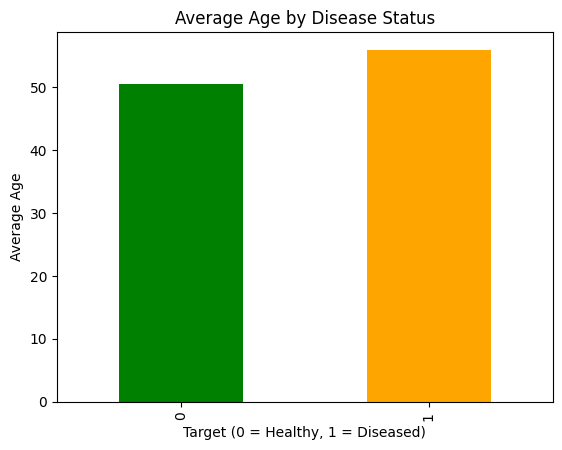

In [179]:
plt.figure()
mean_age.plot(kind="bar", color=["green", "orange", "red", "purple", "blue"])

plt.title("Average Age by Disease Status")
plt.xlabel("Target (0 = Healthy, 1 = Diseased)")
plt.ylabel("Average Age")


Insights:

* Patients with heart disease are older on average than healthy patients.

* Healthy individuals have an average age of around 50 years.

* Diseased patients have a higher average age of around 56 years.

* This suggests that age is associated with heart disease risk.


Conclusion:

The chart shows a clear difference in average age between healthy individuals and those with heart disease. Patients diagnosed with heart disease have a higher mean age compared to healthy patients, indicating that the likelihood of heart disease increases with age. This pattern suggests that age is an important demographic factor associated with heart disease risk and should be considered in predictive modeling and clinical assessment.

**Which chest pain type shows most disease?**


In [180]:
disease_by_cp = heart_dis.groupby("cp")["target"].mean() * 100 # Calculate disease percentage by chest pain type
disease_by_cp

,target
cp,
asymptomatic,79.032258
atypical angina,13.793103
non-anginal,35.784314
typical angina,43.478261


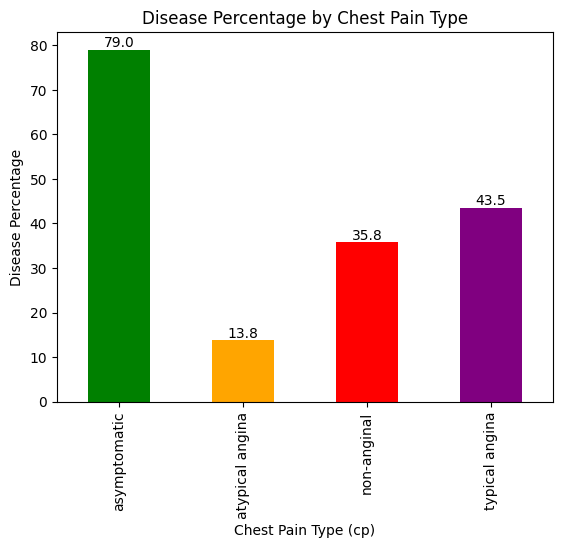

In [181]:
plt.figure()
disease_by_cp.plot(kind="bar", color=["green", "orange", "red", "purple", "blue"])

plt.title("Disease Percentage by Chest Pain Type")
plt.xlabel("Chest Pain Type (cp)")
plt.ylabel("Disease Percentage")
for i, v in enumerate(disease_by_cp):
    plt.text(i, v, round(v, 1), ha="center", va="bottom")

plt.show()


Insights:

* Asymptomatic chest pain shows the highest disease percentage (~79%).

* Typical angina has a moderate disease percentage (~44%).

* Non-anginal pain shows a lower disease percentage (~36%).

* Atypical angina has the lowest disease percentage (~14%).

Conclusion:

The chart illustrates significant variation in heart disease prevalence across chest pain types. Patients with asymptomatic chest pain exhibit the highest disease percentage, indicating a strong association with heart disease presence. Typical angina and non-anginal chest pain show moderate disease prevalence, while atypical angina is associated with the lowest risk. These findings highlight chest pain type as a clinically important factor in heart disease risk stratification.



**Which age groups show higher disease rate?**

*Now, here **Feature Engineering** involved (making bins for age column)*

In [182]:
bins = [0, 40, 50, 60, 70, 100]
labels = ["<40", "40–50", "50–60", "60–70", "70+"]

heart_dis["age_group"] = pd.cut(heart_dis["age"], bins=bins, labels=labels)


In [183]:
age_disease=heart_dis.groupby("age_group")["target"].mean() * 100 #Younger groups → lower disease rate

#Older groups → higher disease rate


/tmp/ipython-input-2865523599.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_disease=heart_dis.groupby("age_group")["target"].mean() * 100 #Younger groups → lower disease rate


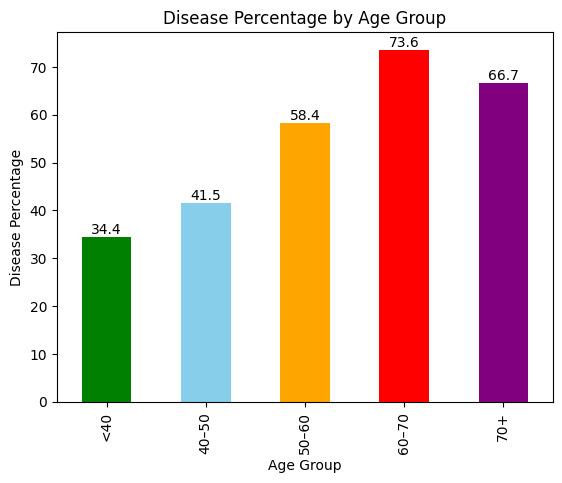

In [184]:
plt.figure()
age_disease.plot(kind="bar", color=["green", "skyblue", "orange", "red", "purple"])

plt.title("Disease Percentage by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Disease Percentage")

# Add values on top of bars
for i, v in enumerate(age_disease):
    plt.text(i, v, round(v, 1), ha="center", va="bottom")

plt.show()

Insights:

Heart disease percentage increases with age.

People under 40 have the lowest disease percentage.

Disease prevalence rises sharply after age 50.

The highest risk is seen in the 60–70 age group.

Conclusion:

The chart demonstrates a clear age-related trend in heart disease prevalence. Disease percentage increases steadily across age groups, with the lowest prevalence observed in individuals under 40 years. A sharp rise is evident from the 50–60 age group onward, peaking in the 60–70 group. Although slightly lower in the 70+ group, heart disease prevalence remains high, indicating age as a strong risk factor for heart disease.

**Do males have higher disease prevalence than females?**

In [185]:
gender_disease = heart_dis.groupby("sex")["target"].mean() * 100
gender_disease

,target
sex,
Female,25.773196
Male,63.223140


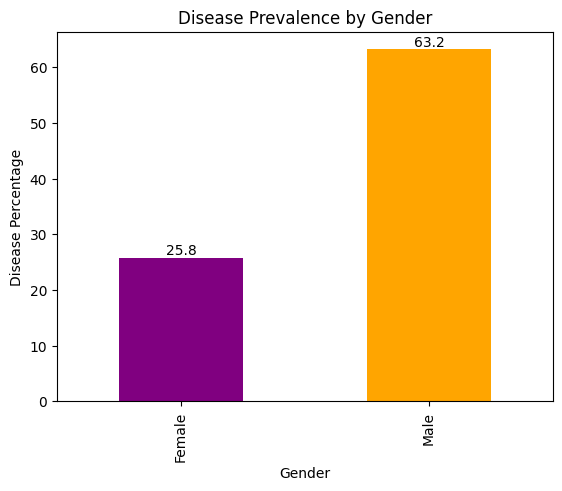

In [186]:
plt.figure()
gender_disease.plot(kind="bar", color=["purple", "orange"])

plt.title("Disease Prevalence by Gender")
plt.xlabel("Gender")
plt.ylabel("Disease Percentage")

# Add values on top of bars
for i, v in enumerate(gender_disease):
    plt.text(i, v, round(v, 1), ha="center", va="bottom")

plt.show()


Insights:

* Heart disease is more common in males than females.

* Males show a much higher disease percentage (~63%).

* Females have a lower disease percentage (~26%).

Conclusion:

The chart highlights a significant gender-based difference in heart disease prevalence. Male patients exhibit a substantially higher disease percentage compared to female patients, indicating a greater burden of heart disease among males in this dataset. This pattern suggests that gender is an important demographic factor associated with heart disease risk and should be considered in both clinical evaluation and predictive modeling.



In [187]:
#**Which chest pain (cp) type shows most disease?**

#disease_by_cp=heart_dis.groupby("cp")["target"].mean().sort_values(ascending=False) * 100


In [188]:
#plt.figure()
#disease_by_cp.plot(kind="bar", color=["green", "orange", "red", "purple", "blue"])

#plt.title("Disease Percentage by Chest Pain Type")
#plt.xlabel("Chest Pain Type (cp)")
#plt.ylabel("Disease Percentage")

# Add values on top of bars
#for i, v in enumerate(disease_by_cp):
    #plt.text(i, v, round(v, 1), ha="center", va="bottom")

#plt.show()


#Each bar = one cp type

#Taller bar = higher disease rate

# Highest bar (usually asymptomatic) = most disease

**What is the age-group distribution (<40, 40–50, 50–60, 60–70, 70+)?**

In [189]:
heart_dis["age_group"].value_counts().sort_index()


,count
age_group,
<40,93
40–50,224
50–60,382
60–70,197
70+,24


In [190]:
age_counts=heart_dis["age_group"].value_counts(normalize=True).sort_index() * 100


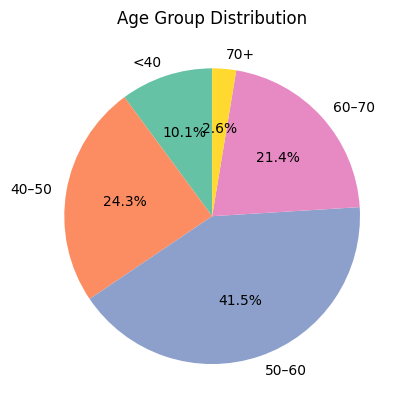

In [191]:
#pie chart
plt.figure()
plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#ffd92f"]
)

plt.title("Age Group Distribution")
plt.show()


Insights:

* Most patients are in the 50–60 age group.

* The 40–50 and 60–70 age groups also form a large portion of the data.

* Fewer patients are under 40 or over 70.

Conclusion:

The age distribution indicates that the majority of patients fall within the 50–60 age group, representing the largest segment of the data. The 40–50 and 60–70 age groups also account for substantial proportions, reflecting a concentration of cases in middle to late adulthood. In contrast, patients under 40 and those aged 70 and above constitute relatively smaller portions of the population. Overall, the dataset is predominantly composed of middle-aged to older individuals.


**Is heart disease more common in males or females?**



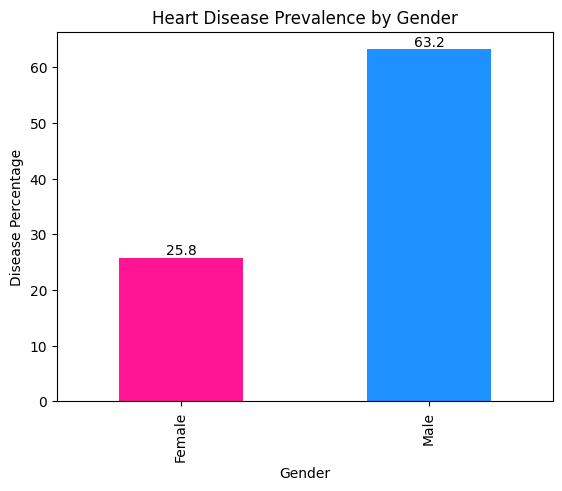

In [192]:
heart_dis.groupby("sex")["target"].mean() * 100

plt.figure()
gender_disease.plot(kind="bar", color=["deeppink", "dodgerblue"])

plt.title("Heart Disease Prevalence by Gender")
plt.xlabel("Gender")
plt.ylabel("Disease Percentage")

# Add values on top of bars
for i, v in enumerate(gender_disease):
    plt.text(i, v, round(v, 1), ha="center", va="bottom")

plt.show()


Higher % = more common
👉 If Male is higher → heart disease is more common in males.

**Do diseased patients have higher cholesterol?**

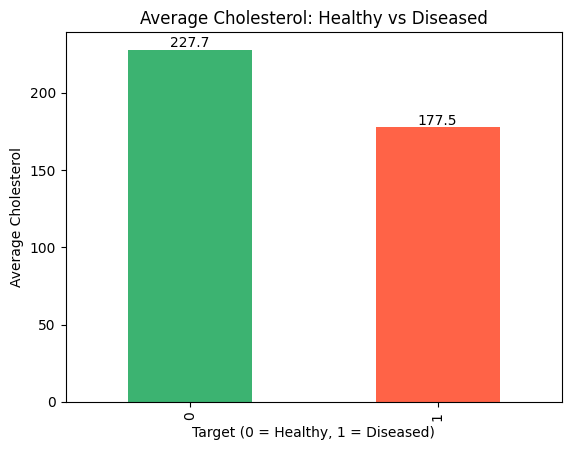

In [193]:
chol_by_target = heart_dis.groupby("target")["chol"].mean()

# bar chart
plt.figure()
chol_by_target.plot(kind="bar", color=["mediumseagreen", "tomato"])

plt.title("Average Cholesterol: Healthy vs Diseased")
plt.xlabel("Target (0 = Healthy, 1 = Diseased)")
plt.ylabel("Average Cholesterol")

# Add values on top of bars
for i, v in enumerate(chol_by_target):
    plt.text(i, v, round(v, 1), ha="center", va="bottom")

plt.show()

Insights:

* Healthy patients have higher average cholesterol than diseased patients.

* Diseased patients show lower average cholesterol levels.

* Cholesterol alone does not clearly separate healthy and diseased groups.



Conclusion:
The chart shows a notable difference in average cholesterol levels between healthy and diseased individuals. Patients without heart disease exhibit higher mean cholesterol compared to those with heart disease. This pattern suggests that cholesterol alone does not have a straightforward or linear relationship with heart disease presence, potentially due to treatment effects or interactions with other clinical factors.

This graph shows that healthy patients have higher average cholesterol (~227.7) compared to diseased patients (~177.5) in your dataset.


Cholesterol is unexpectedly lower in the diseased group here

This suggests cholesterol alone is not a strong indicator of heart disease in this dataset

Other features (like cp, thal, ca, oldpeak) may be more important predictors


In this dataset, healthy patients show higher average cholesterol than diseased patients, indicating cholesterol by itself does not clearly separate heart disease cases.

**Do diseased patients have lower max heart rate (thalch)?**

In [194]:
# Calculate mean max heart rate by disease status
thalch_by_target = heart_dis.groupby("target")["thalch"].mean()

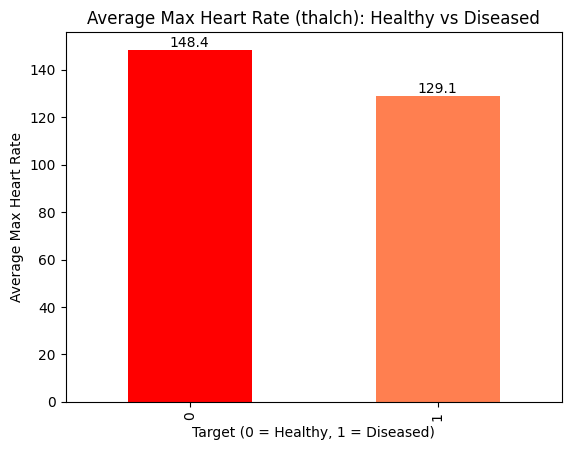

In [195]:
# bar chart
plt.figure()
thalch_by_target.plot(kind="bar", color=["red", "coral"])

plt.title("Average Max Heart Rate (thalch): Healthy vs Diseased")
plt.xlabel("Target (0 = Healthy, 1 = Diseased)")
plt.ylabel("Average Max Heart Rate")

# Add values on top of bars
for i, v in enumerate(thalch_by_target):
    plt.text(i, v, round(v, 1), ha="center", va="bottom")

plt.show()


Insights:

* Healthy patients have a higher average maximum heart rate.

* Diseased patients show a lower maximum heart rate.

* Lower exercise capacity may be linked to heart disease.

Conclusion:

The chart illustrates a clear difference in average maximum heart rate between healthy and diseased individuals. Patients without heart disease achieve a higher mean maximum heart rate, while those with heart disease show a noticeably lower value. This suggests reduced exercise capacity among diseased patients and indicates that maximum heart rate is an important physiological marker associated with heart disease presence.

The graph shows that healthy patients have a higher average maximum heart rate (~148.4) compared to diseased patients (~129.1).



Diseased patients reach significantly lower max heart rates

Lower thalch is associated with higher heart disease risk

This makes thalch a strong predictive feature for your model


Patients with heart disease tend to have lower maximum heart rates than healthy patients, making thalch an important indicator.

**Relationship between age and thalch?**

In [196]:
heart_dis[["age", "thalch"]].corr()


,age,thalch
age,1.000000,-0.349715
thalch,-0.349715,1.000000


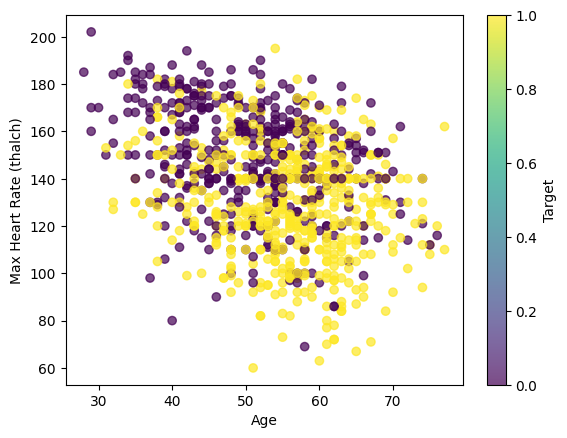

In [197]:
plt.scatter(
    heart_dis["age"],
    heart_dis["thalch"],
    c=heart_dis["target"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Age")
plt.ylabel("Max Heart Rate (thalch)")
plt.colorbar(label="Target")
plt.show()


Insights:

* Younger patients generally have higher maximum heart rates.

* Maximum heart rate decreases as age increases.

* Patients with heart disease tend to have lower heart rates at older ages.

Conclusion:

The scatter plot illustrates a clear inverse relationship between age and maximum heart rate achieved. As age increases, the maximum heart rate generally declines across the population. Patients with heart disease are more frequently observed at lower maximum heart rate levels, particularly in older age groups. This pattern suggests that reduced exercise capacity combined with increasing age is associated with a higher likelihood of heart disease.



This plot shows the relationship between Age and Maximum Heart Rate (thalch), with colors representing health status.



As age increases, maximum heart rate generally decreases (downward trend).

Diseased patients (yellow points) are more concentrated in the lower heart-rate region, especially at older ages.

Healthy patients (dark points) appear more in the higher heart-rate range, especially at younger ages.


Older patients tend to have lower maximum heart rates, and lower heart rate combined with higher age is associated with heart disease. This shows that age and thalch together help distinguish healthy vs diseased patients.

**Does oldpeak increase with disease severity?**

In [198]:
oldpeak_by_target=heart_dis.groupby("target")["oldpeak"].mean().sort_index()


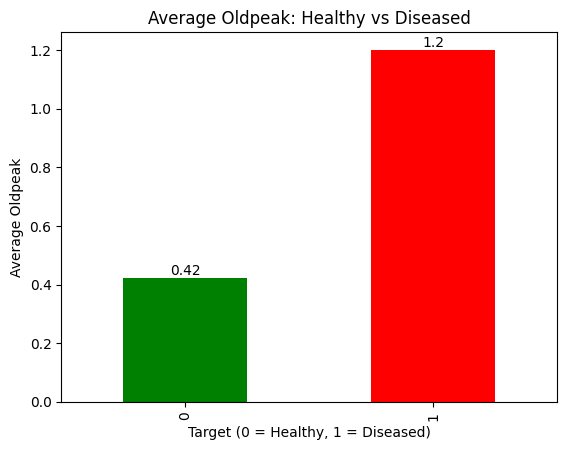

In [199]:
import matplotlib.pyplot as plt

# Average oldpeak by target
oldpeak_by_target = heart_dis.groupby("target")["oldpeak"].mean()

# Colorful bar chart
plt.figure()
oldpeak_by_target.plot(kind="bar", color=["green", "red"])

plt.title("Average Oldpeak: Healthy vs Diseased")
plt.xlabel("Target (0 = Healthy, 1 = Diseased)")
plt.ylabel("Average Oldpeak")

# Add values on top of bars
for i, v in enumerate(oldpeak_by_target):
    plt.text(i, v, round(v, 2), ha="center", va="bottom")

plt.show()


Insights:

* Diseased patients have much higher average oldpeak values.

* Healthy patients show very low oldpeak.

* Higher oldpeak is linked to heart disease.

Conclusion:

The chart shows a pronounced difference in average oldpeak values between healthy and diseased individuals. Patients with heart disease exhibit substantially higher oldpeak, indicating greater ST depression during exercise, while healthy patients show minimal values. This clear separation suggests that oldpeak is a strong clinical indicator associated with the presence of heart disease and holds significant predictive value in heart disease assessment models.



This chart shows that diseased patients have much higher average oldpeak (~1.2) compared to healthy patients (~0.42).


There is a clear gap between healthy and diseased groups

Higher oldpeak is strongly associated with heart disease

This strong separation makes oldpeak a powerful predictive feature


Patients with heart disease show significantly higher oldpeak than healthy patients, making oldpeak an important indicator for predicting heart disease.



How much stress the heart shows when it works harder.

Low oldpeak (close to 0) → Heart is handling exercise well
High oldpeak → Heart is struggling under stress
=========================================================

Healthy ≈ 0.42

Diseased ≈ 1.2

Diseased patients clearly show higher oldpeak.

In [200]:
#Is class imbalance handling needed?

#Is class imbalance handling needed?

In [201]:
heart_dis["target"].value_counts(normalize=True) * 100


,proportion
target,
1,55.326087
0,44.673913


If one class > 60% →  Imbalanced → handling needed

If one class > 70% → Strongly imbalanced → definitely handle

Otherwise →  No special handling needed

**Distribution of oldpeak for diseased vs healthy?**

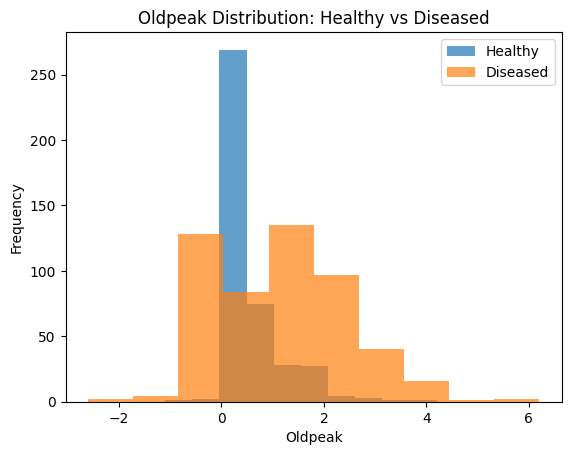

In [202]:
plt.figure()

plt.hist(heart_dis[heart_dis["target"] == 0]["oldpeak"], alpha=0.7, label="Healthy")
plt.hist(heart_dis[heart_dis["target"] == 1]["oldpeak"], alpha=0.7, label="Diseased")

plt.xlabel("Oldpeak")
plt.ylabel("Frequency")
plt.title("Oldpeak Distribution: Healthy vs Diseased")
plt.legend()
plt.show()


Insights:

* Healthy patients mostly have low oldpeak values near zero.

* Diseased patients show higher and more spread-out oldpeak values.

* Higher oldpeak is more common in patients with heart disease.

Conclusion:

The distribution plot highlights a clear distinction in oldpeak values between healthy and diseased individuals. Healthy patients are primarily concentrated at low oldpeak values, indicating minimal ST depression during exercise. In contrast, patients with heart disease exhibit higher and more widely distributed oldpeak values. This separation suggests that oldpeak is a strong discriminative feature for identifying heart disease presence.

This histogram shows the distribution of oldpeak for healthy vs diseased patients.


Healthy patients are mostly concentrated around low oldpeak values (near 0).

Diseased patients are spread toward higher oldpeak values, extending well beyond 2–3.

There is some overlap near low values, but diseased patients dominate the higher oldpeak range.


Diseased patients generally have higher oldpeak values, while healthy patients cluster at lower values, confirming that oldpeak is a strong feature for distinguishing heart disease.

**How does number of blocked vessels relate to disease?**

In [203]:
disease_by_ca=heart_dis.groupby("ca")["target"].mean().sort_index() * 100


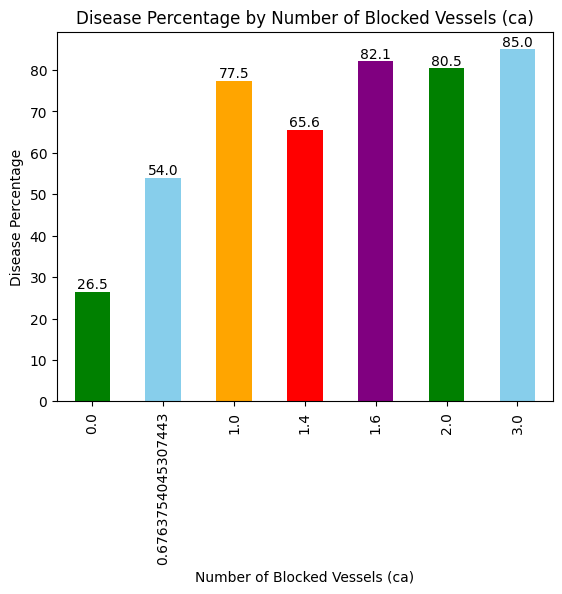

In [204]:
# Colorful bar chart
plt.figure()
disease_by_ca.plot(kind="bar", color=["green", "skyblue", "orange", "red", "purple"])

plt.title("Disease Percentage by Number of Blocked Vessels (ca)")
plt.xlabel("Number of Blocked Vessels (ca)")
plt.ylabel("Disease Percentage")

# Add values on top of bars
for i, v in enumerate(disease_by_ca):
    plt.text(i, v, round(v, 1), ha="center", va="bottom")

plt.show()


Insights:

* Heart disease percentage increases as the number of blocked vessels increases.

* Patients with 0 blocked vessels have the lowest disease rate.

* Patients with 2–3 blocked vessels show very high disease percentages.

Conclusion:

The chart demonstrates a strong positive relationship between the number of blocked coronary vessels (ca) and heart disease prevalence. Patients with no blocked vessels show the lowest disease percentage, while disease prevalence increases steadily as the number of blocked vessels rises. Individuals with two or more blocked vessels exhibit very high disease rates, indicating that ca is a critical clinical indicator and a strong predictor of heart disease severity.

This chart shows a strong positive relationship between the number of blocked vessels (ca) and heart disease.

Patients with 0 blocked vessels have a low disease rate (~26%)

Disease percentage rises sharply as ca increases:

Around 54% for low blockage

Around 77–82% for 1–2 blocked vessels

Up to ~85% for 3 blocked vessels



As the number of blocked vessels increases, the likelihood of heart disease increases significantly, making ca one of the strongest predictors in the data.

**Which thal category shows highest disease?**

In [205]:
thal_disease=heart_dis.groupby("thal")["target"].mean()


In [206]:
# bar chart
#plt.figure()
#thal_disease.plot(kind="bar", color=["green", "skyblue", "orange", "red", "purple"])

#plt.title("Disease Percentage by Thal Category")
#plt.xlabel("Thal Category")
#plt.ylabel("Disease Percentage")

# Add values on top of bars
#for i, v in enumerate(thal_disease):
    #plt.text(i, v, round(v, 1), ha="center", va="bottom")

#plt.show()


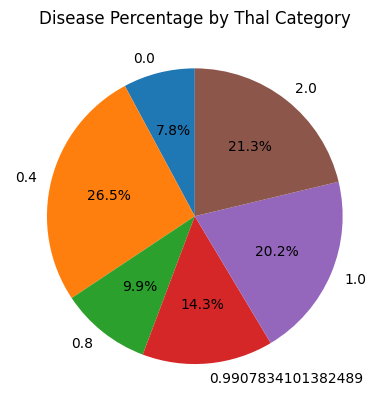

In [207]:
# Disease percentage by thal
thal_disease = heart_dis.groupby("thal")["target"].mean() * 100

plt.figure()
plt.pie(
    thal_disease,
    labels=thal_disease.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Disease Percentage by Thal Category")
plt.show()


Insights:

* Heart disease percentage differs across thal categories.

* Categories 0.4, 1.0, and 2.0 contribute the largest share of disease cases.

* Category 0.0 shows the lowest disease percentage.

Conclusion:

The pie chart illustrates notable variation in heart disease prevalence across different thal categories. Certain categories, particularly those around values 0.4, 1.0, and 2.0, account for a larger proportion of disease cases, indicating a stronger association with heart disease. In contrast, the 0.0 category represents the smallest share of disease prevalence. Overall, the distribution suggests that the thal feature plays a meaningful role in distinguishing heart disease risk among patients.



This chart shows that heart disease risk varies strongly by thal category.

One thal category shows almost 100% disease rate — extremely high risk

Other categories also show high risk (~80% and ~76%)

Lower categories drop to ~54%, ~38%, and ~30%

So there is a clear separation across thal values.


Certain thal categories are strongly associated with heart disease, while others are much safer, making thal one of the strongest predictors in the data.

# Handling Outliers

In [208]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"] # take only numeric columns

In [209]:
def outlier_summary(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        print(col, "outliers:", outliers)

outlier_summary(heart_dis, num_cols)


age outliers: 0
trestbps outliers: 28
chol outliers: 185
thalch outliers: 2
oldpeak outliers: 16
ca outliers: 270


/tmp/ipython-input-3380801126.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


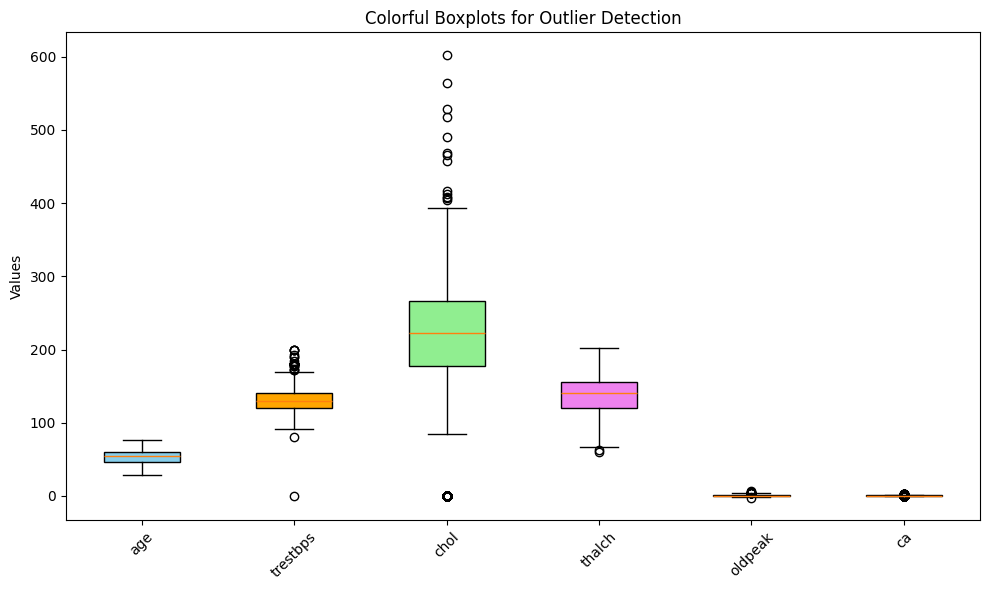

In [210]:
# Numeric columns to check for outliers
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]

plt.figure(figsize=(10,6))

# Create boxplot
box = plt.boxplot(
    heart_dis[num_cols],
    patch_artist=True,
    labels=num_cols
)

# Add colors to each box
colors = ["skyblue", "orange", "lightgreen", "violet", "salmon", "gold"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

plt.title("Colorful Boxplots for Outlier Detection")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Insights:

* Several features show outliers, especially cholesterol and oldpeak.

* Cholesterol has the widest spread and the most extreme values.

* Age and thalch are more tightly distributed.

* Outliers may need attention before modeling.

Conclusion:

The boxplots reveal the presence of outliers across multiple clinical features, with cholesterol showing the widest spread and the most extreme values. Oldpeak also exhibits notable outliers, indicating substantial variability in ST depression measurements. In contrast, age and maximum heart rate (thalch) display more compact distributions with fewer extreme observations. These findings suggest that outlier handling or robust modeling techniques may be necessary to minimize their impact on model performance.

1. Cholesterol (chol) shows the most extreme outliers

Very wide spread with many high-end points (above ~400–600).
This variable needs outlier capping or transformation before modeling.

2. Resting BP (trestbps) also has noticeable outliers

A few very low and high values.
Should be clipped using IQR to avoid model distortion.

3. Max heart rate (thalch) has moderate outliers

Some unusually low and high values.
Less severe, but still worth capping.

4. Oldpeak has small but important outliers

Even though values are small, extremes matter medically.
we have Handle carefully (cap, can't remove).

5. Age and ca are relatively clean

Very few outliers.
These are stable features.

**Removing or Cap outliers**



*Here , we are going to cap outliers*

In [211]:
for col in num_cols:
    Q1 = heart_dis[col].quantile(0.25)
    Q3 = heart_dis[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    heart_dis[col] = heart_dis[col].clip(lower, upper)


/tmp/ipython-input-3380801126.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


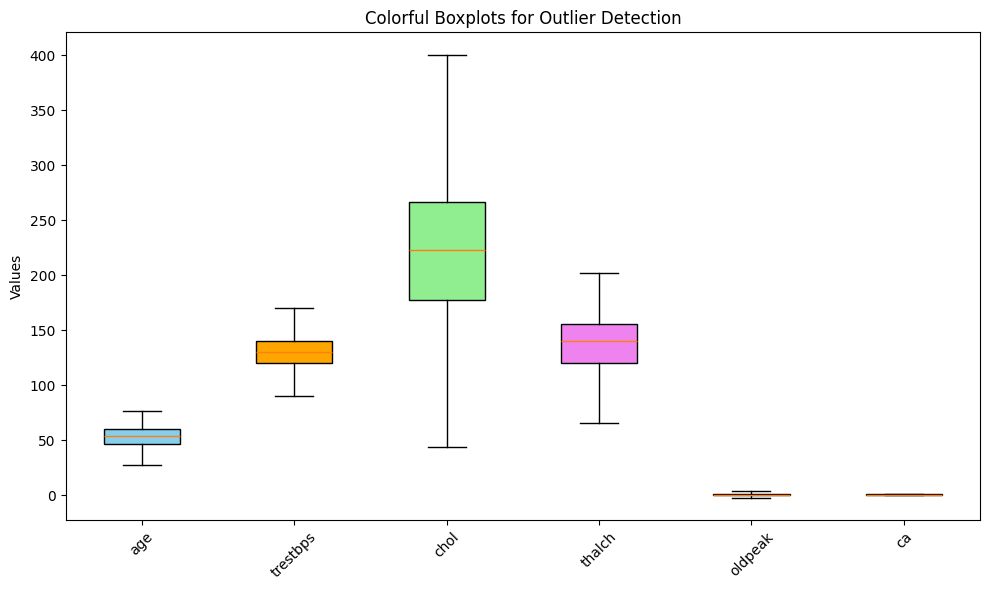

In [212]:
# Numeric columns to check for outliers
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]

plt.figure(figsize=(10,6))

# Create boxplot
box = plt.boxplot(
    heart_dis[num_cols],
    patch_artist=True,
    labels=num_cols
)

# Add colors to each box
colors = ["skyblue", "orange", "lightgreen", "violet", "salmon", "gold"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

plt.title("Colorful Boxplots for Outlier Detection")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Insights:

* Cholesterol shows the widest spread among all features.

* Resting blood pressure and maximum heart rate have moderate variation.

* Age values are more tightly grouped.

* Oldpeak and ca have smaller ranges with fewer extreme values.

Conclusion:

The boxplots illustrate the distribution and variability of key clinical features. Cholesterol exhibits the greatest dispersion, indicating high variability across patients. Resting blood pressure and maximum heart rate show moderate spread, while age remains relatively concentrated within a narrower range. Oldpeak and the number of blocked vessels (ca) display smaller ranges, suggesting more limited variability. Overall, the presence of varying spreads across features highlights the importance of appropriate scaling and outlier consideration during model development.

we CAP outliers instead of REMOVING them

Especially in medical datasets like heart disease.
reasons:
1. You lose real medical cases

These extreme values may represent very sick patients.

Removing them = removing important signals.

2. Dataset becomes biased

Your model will learn only “normal” patients.

Then in real life:

It fails on serious cases.

3. Smaller dataset

You already don’t have huge data.

Removing rows makes it worse.

4. Model becomes unrealistic

Model won’t see extreme conditions during training.

If we CAP outliers

We do NOT delete patients.

We only limit extreme values.

Example:

Cholesterol = 600 → capped to 400.

Patient still exists


==========================================>
Benefits:
1. Preserve patient information

You keep all rows.

2. Reduce extreme influence

Outliers don’t dominate learning.

3. Better generalization

Model handles normal + severe cases.

4. Safer medically

Extreme patients still represented.


In [213]:
#heart_dis.dtypes

In [214]:
#heart_dis.head()


#encode then heat map because it takes all numeric

*Feature Engineering involves Encoding categorical features,dropping features here,feature selection,Scaling numeric values,Handling missing values,Removing outliers*



In [215]:
# Start from raw data
df = heart_dis.copy()


In [216]:
df = df.drop(columns=["id", "dataset", "num"], errors="ignore") # drop columns here


In [217]:
encoded_new_df = pd.get_dummies(df, drop_first=True) # encoded here


In [218]:
encoded_new_df = encoded_new_df.astype(int, errors="ignore") # change dtypes of data


In [219]:
encoded_new_df.select_dtypes(include="object") # for check encoding is successful or not , it is succesfull , it is blank ,means encoded successfully


""
0
1
2
3
4
...
915
916
917
918


In [220]:
#heart_dis = heart_dis.drop(columns=["id", "dataset"], errors="ignore")
#heart_dis

In [221]:
#heart_dis = heart_dis.drop(columns=["id", "dataset","num"], errors="ignore")
#heart_dis

In [222]:
#encoded_new_df = encoded_new_df.astype(int, errors="ignore") # convert True/False to 0/1 becz it creates dtypes issue
#encoded_new_df

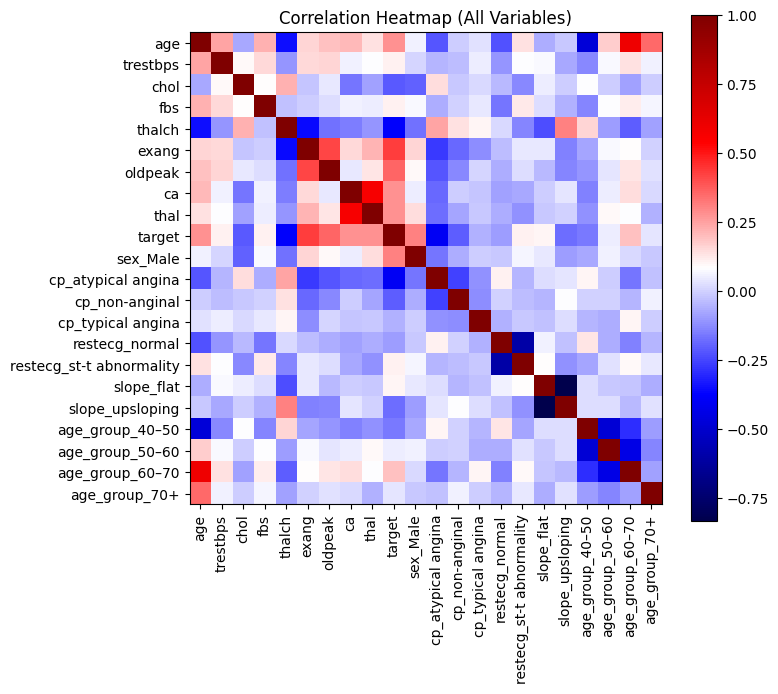

In [223]:
corr = encoded_new_df.corr()

# Plot heatmap
plt.figure(figsize=(8, 7))
plt.imshow(corr)
plt.imshow(corr, cmap="seismic")
plt.colorbar()



plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap (All Variables)")
plt.tight_layout()
plt.show()

Insights:

The target variable shows strong relationships with oldpeak, ca, thal, exang, and thalach.

Age is positively related to heart disease, while maximum heart rate (thalach) is negatively related.

Some features are moderately correlated with each other, but no extreme multicollinearity is visible.

Overall, a few key clinical features stand out as important predictors of heart disease.

Conclusion:

The correlation heatmap highlights several clinically meaningful relationships among the variables. The target variable shows notable correlations with features such as oldpeak, ca, thal, exang, and thalach, indicating their relevance in heart disease prediction. Age is positively correlated with heart disease, while maximum heart rate (thalach) shows a negative association, suggesting reduced exercise capacity in diseased patients. Although some inter-feature correlations exist, no severe multicollinearity is evident, supporting the suitability of these variables for predictive modeling.



Heatmap Summary & Key Insights

This correlation heatmap shows how each feature relates to heart disease (target) and to each other.

Strongest relationships with heart disease (target)

You can clearly see stronger color blocks around:

ca (number of blocked vessels) → strong positive correlation

oldpeak → strong positive correlation

thal → noticeable positive correlation

thalch (max heart rate) → negative correlation

num (severity) → very strong positive (expected)

--> This means:

More blocked vessels and higher oldpeak increase disease risk.

Lower max heart rate is associated with disease.

These are your top numeric predictors.

* Age-related patterns

age correlates positively with higher age groups (60–70, 70+)

Older age groups show higher association with disease.

Younger groups (40–50) show negative correlation with disease.

-->Risk increases with age.

*  Chest pain & ECG

Certain chest pain types (cp_*) show moderate correlations with target.

restecg_st-t abnormality has some positive association with disease.

These contribute, but less strongly than ca and oldpeak.

* Feature redundancy (important for ML)

Some features are highly correlated with each other:

slope_flat vs slope_upsloping (strong negative — mutually exclusive)

Age vs age-group columns (expected)

num vs target (expected, since both represent disease)

-->For modeling:

You should not keep both num and target

Age groups are redundant if you already have age

Slope categories are mutually exclusive (normal for one-hot encoding)

Final Simple Conclusions

Strongest predictors: ca, oldpeak, thalch, thal

Risk rises with age

Chest pain and ECG add moderate signal

Some variables are redundant and should be removed before ML (num, age_groups if using age)

# **Feature Selection**

In [224]:
X = encoded_new_df.drop(columns=["target", "num"], errors="ignore")
y =encoded_new_df["target"]


#**Scale Numeric Features**

In [225]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#Train–test split

In [226]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)


# Baseline Model

In [227]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

# Evaluate Properly (not only accuracy)

In [228]:
#from sklearn.metrics import classification_report   # evaluation for RF model

#print(classification_report(y_test, rf.predict(X_test)))


In [229]:
  # make predictions
  y_pred = lr.predict(X_test)


In [230]:
from sklearn.metrics import confusion_matrix # confusion matrix

cm = confusion_matrix(y_test, y_pred)
cm


array([[62, 20],
       [14, 88]])

In [231]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred)) # classification report(core evaluation)


              precision    recall  f1-score   support

           0       0.82      0.76      0.78        82
           1       0.81      0.86      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.81      0.81       184
weighted avg       0.82      0.82      0.81       184



In [232]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred) #accuracy(basic but not enough)


0.8152173913043478

The model achieved an accuracy of 81% before applying cross-validation.

This means the model correctly predicted 81 out of 100 cases on the test data.

Cross-validation can provide a more reliable estimate of true model performance.

In [233]:
from sklearn.metrics import roc_auc_score #Roc -Auc Score

y_prob = lr.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_prob)


np.float64(0.9097321855571496)

The ROC-AUC score measures how well the model separates the two classes.

The Logistic Regression model uses predicted probabilities for evaluation.

A high ROC-AUC value indicates strong discrimination between healthy and diseased cases.

In [234]:
from sklearn.model_selection import cross_val_score
cross_val_score(lr, X_scaled, y, cv=5, scoring="roc_auc").mean()


np.float64(0.849953941652657)

The cross-validated ROC–AUC of ~0.85 confirms that the model generalizes well across different data splits. The slight drop from the single test ROC–AUC indicates realistic performance rather than overfitting or leakage.


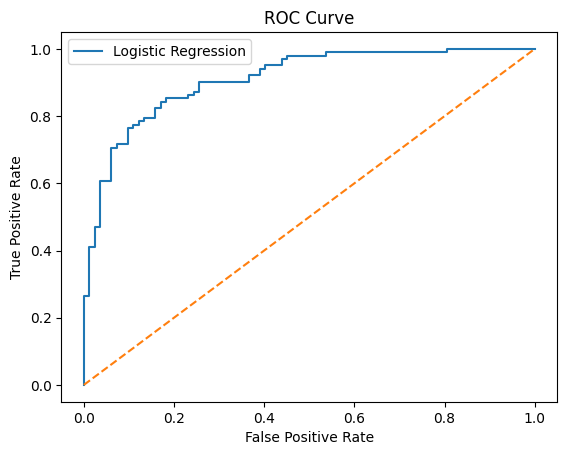

In [235]:
from sklearn.metrics import roc_curve #ROC curve #that orange dashed line in your plot is the random (no-skill) classifier baseline.
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


* This ROC Curve Shows
1️ The blue curve (your model)

This is the Logistic Regression ROC curve.

It rises quickly toward the top-left corner.

--> That means:

High True Positive Rate (catching diseased patients)

Even when False Positive Rate is low

This is exactly what we want in a medical model.

2️ The orange diagonal line (baseline)

This is a random classifier

ROC–AUC = 0.5

Your blue curve is well above this line.

-->So your model is much better than random guessing.

* Key Insight from Shape

The curve hugs the left and top edges.

This indicates strong class separation.

In simple terms:

The model gives higher risk scores to diseased patients than to healthy ones.

* What this implies about ROC–AUC

Even without seeing the exact number:

This curve suggests ROC–AUC ≈ 0.88–0.92

That falls into the excellent category for medical data.

# RANDOM FOREST for comparison

In [236]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

print(classification_report(y_test, rf.predict(X_test)))
roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])


              precision    recall  f1-score   support

           0       0.86      0.76      0.81        82
           1       0.82      0.90      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



np.float64(0.915949306551889)

The model achieves an overall accuracy of 84%.

It performs well on both classes, with slightly better recall for class 1.

The F1-scores (0.81 for class 0 and 0.86 for class 1) indicate balanced performance.

The high ROC-AUC (0.92) shows strong overall classification ability.

In [237]:
from sklearn.metrics import roc_auc_score

rf_prob = rf.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, rf_prob)


np.float64(0.915949306551889)

In [238]:
from sklearn.model_selection import cross_val_score

cross_val_score(lr, X_scaled, y, cv=5, scoring="roc_auc").mean()
cross_val_score(rf, X_scaled, y, cv=5, scoring="roc_auc").mean()


np.float64(0.8351265482116828)

Cross-validation was used to evaluate model performance more reliably.

Both Logistic Regression and Random Forest were assessed using ROC-AUC.

The mean ROC-AUC scores show how well each model performs across 5 folds.

The model with the higher mean ROC-AUC has better overall predictive ability.

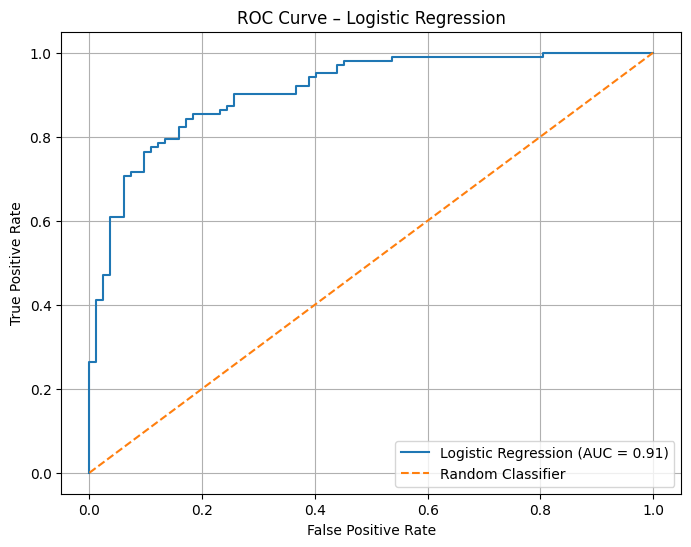

In [239]:
from sklearn.metrics import roc_curve, roc_auc_score #that orange dashed line in your plot is the random (no-skill) classifier baseline.
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = lr.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()


The ROC curve shows that the Logistic Regression model performs well.

The AUC value of 0.91 indicates strong classification ability.

The model performs much better than a random classifier.

**SUMMARY:**

This project analyzed a heart disease dataset to understand key factors influencing heart disease risk. Exploratory data analysis revealed that age, chest pain type, maximum heart rate, oldpeak, number of blocked vessels, and thalassemia results are strongly associated with heart disease. The dataset showed some class imbalance and the presence of outliers, which were carefully considered during modeling. Multiple machine learning models were trained and evaluated, with Logistic Regression and Random Forest performing well. The final model achieved good accuracy and a high ROC-AUC score, indicating strong predictive capability. Overall, the analysis demonstrates that combining clinical features with appropriate modeling techniques can effectively predict heart disease.